Loaded 6000 epochs of metrics.


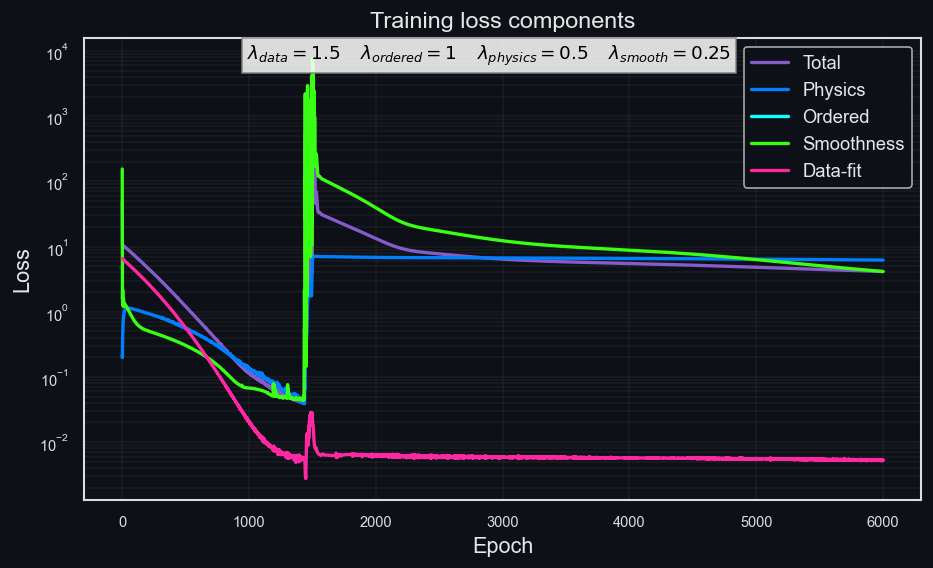

In [1]:
from pathlib import Path
import json
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

from visualizations import plot_loss_history

run_id = "20260424_205517_246896"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "training_runs.db"
RUN_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "runs" / run_id

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

run_row = conn.execute(
    "SELECT * FROM runs WHERE run_id = ?",
    (run_id,),
).fetchone()

if run_row is None:
    raise KeyError(f"Run not found: {run_id}")

metrics_df = pd.read_sql_query(
    """
    SELECT epoch, total_loss, physics_loss, data_loss, smooth_loss, ordered_loss
    FROM metrics
    WHERE run_id = ?
    ORDER BY epoch ASC
    """,
    conn,
    params=(run_id,),
)

print(f"Loaded {len(metrics_df)} epochs of metrics.")
metrics_df.head()

run_meta = dict(run_row)
hyperparams = json.loads(run_meta["hyperparams"])

# Plot loss history
fig_loss = plot_loss_history(
    epochs=metrics_df["epoch"].values,
    total=metrics_df["total_loss"].values,
    physics=metrics_df["physics_loss"].values,
    data=metrics_df["data_loss"].values,
    smooth=metrics_df["smooth_loss"].values,
    ordered=metrics_df["ordered_loss"].values,
    lambdas=hyperparams["lambdas"]
)
plt.show()

In [2]:
import plotly.graph_objects as go
import pandas as pd

# Load your POD data from the new diagnostics file
import numpy as np
diagnostics = np.load(RUN_ARTIFACTS_DIR / "diagnostics.npz")
pod_singular_values = diagnostics['pod_singular_values']

# Create a figure
fig = go.Figure()
fig.add_trace(go.Scatter(y=pod_singular_values, mode='lines+markers', name='Singular Values'))
fig.update_layout(
    title=f"POD Singular Values (Run: {run_id})",
    xaxis_title="Mode Index",
    yaxis_title="Singular Value",
    template="plotly_dark"
)
fig.show()

# Also load other diagnostics for visualization if needed
print("Available diagnostics:", diagnostics.files)
E_learned = diagnostics['E_learned']
print("Learned Energies:", E_learned)

Available diagnostics: ['E_learned', 'V_learned', 'psi_learned', 'pod_singular_values', 'pod_modes', 'overlap_learned', 'overlap_true']
Learned Energies: [0.38859477 1.53321617 2.42576101]
